# Day 1: Super-resolution e Deconvoluzione

In questo notebook esploreremo il problema della ricostruzione di immagini degradate da sfocatura (blur) e rumore. Il modello matematico di riferimento è un sistema lineare:

$$
y = A x + n
$$

Dove:
- $y$: Immagine misurata (sfocata e rumorosa)
- $x$: Immagine "vera" (che vogliamo recuperare)
- $A$: Operatore lineare (convoluzione con una PSF - Point Spread Function)
- $n$: Rumore additivo (assunto Gaussiano e non correlato)

## Setup e Librerie
Importiamo le librerie necessarie.  
Useremo `scikit-image` per le immagini di test, `scipy.ndimage` per la convoluzione e `numpy` per algebra lineare e FFT.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from skimage import data, color
from numpy.fft import fft2, ifft2, fftshift, ifftshift

# Funzione di utilità per visualizzare le immagini
def show_images(images, titles, figsize=(15,5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i+1)
        plt.imshow(img, cmap='gray')
        plt.title(title)
        plt.axis('off')
    plt.show()

## 1. Creazione/Caricamento immagine di test
Usiamo l'immagine "camera" (cameraman) di scikit-image, convertita in float [0,1].

Dimensioni immagine: (512, 512)


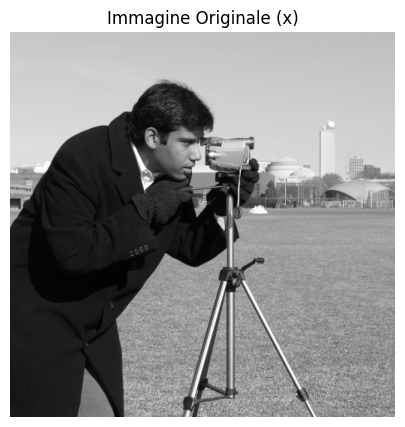

In [10]:
original_image = data.camera().astype(float)/255.0
# Se preferisci l'astronauta:
# original_image = color.rgb2gray(data.astronaut())

print(f"Dimensioni immagine: {original_image.shape}")
show_images([original_image], ["Immagine Originale (x)"])

## Esperimento 1: Inversione Diretta nello Spazio di Fourier

Se trascuriamo il rumore ($n=0$), il sistema diventa $y = Ax$. Se $A$ è una convoluzione con un kernel $h$ (PSF), per il teorema di convoluzione:

$$
F(y) = F(h) \cdot F(x) \quad \Rightarrow \quad \hat{x} = F^{-1}\left( \frac{F(y)}{F(h)} \right)
$$

### 1.1 Creazione della PSF e Sfocatura

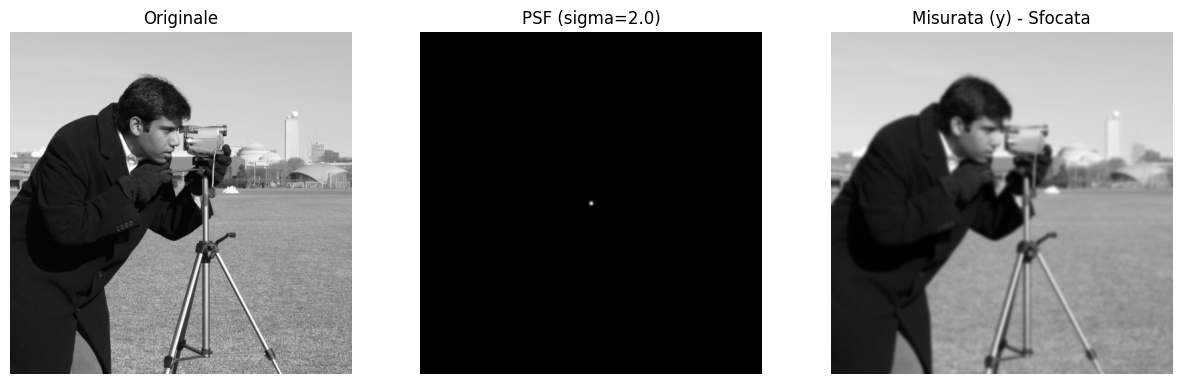

In [15]:
def create_psf(shape, sigma):
    """Crea una PSF Gaussiana centrata nello spazio di Fourier."""
    impulse = np.zeros(shape)
    center = (shape[0]//2, shape[1]//2)
    impulse[center] = 1.0
    psf = ndimage.gaussian_filter(impulse, sigma=sigma)
    return psf

SIGMA = 2.0  # Modifica tra 0.5 e 3.0

psf_spatial = create_psf(original_image.shape, SIGMA)
blurred_image = ndimage.gaussian_filter(original_image, sigma=SIGMA)

show_images([original_image, psf_spatial, blurred_image],
            ["Originale", f"PSF (sigma={SIGMA})", "Misurata (y) - Sfocata"])

### 1.2 Deconvoluzione Diretta (Inverse Filtering)

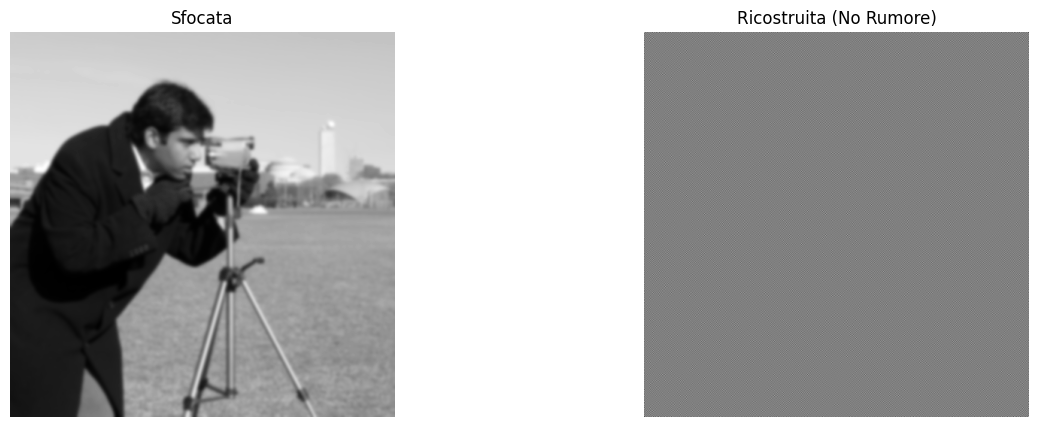

In [16]:
def inverse_filter(blurred_img, psf, epsilon=1e-10):
    """
    Esegue la deconvoluzione nel dominio delle frequenze.
    epsilon serve per evitare divisioni per zero.
    """
    Y = fft2(blurred_img)
    H = fft2(ifftshift(psf))
    H_inv = 1.0 / (H + epsilon)
    X_hat_freq = Y * H_inv
    x_hat = np.real(ifft2(X_hat_freq))
    return x_hat

reconstructed_ideal = inverse_filter(blurred_image, psf_spatial)
show_images([blurred_image, reconstructed_ideal],
            ["Sfocata", "Ricostruita (No Rumore)"])

### 1.b Effetto del Rumore
Aggiungiamo rumore gaussiano all'immagine sfocata.

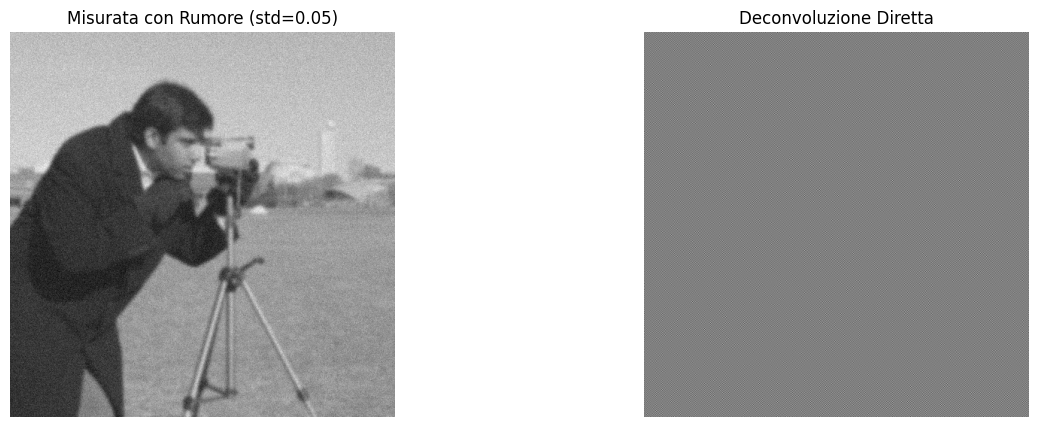

In [17]:
noise_sigma = 0.05
noise = np.random.normal(0, noise_sigma, blurred_image.shape)
y_noisy = blurred_image + noise

reconstructed_noisy = inverse_filter(y_noisy, psf_spatial)
show_images([y_noisy, reconstructed_noisy],
            [f"Misurata con Rumore (std={noise_sigma})", "Deconvoluzione Diretta"])

### 1.c Filtro Inverso Regolarizzato (Wiener-like)

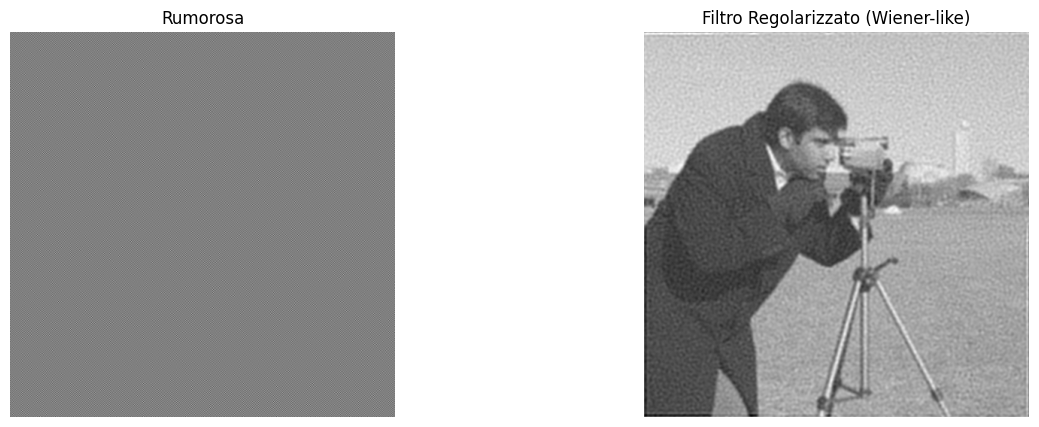

In [18]:
def regularized_inverse_filter(blurred_img, psf, K=0.01):
    Y = fft2(blurred_img)
    H = fft2(ifftshift(psf))
    X_hat_freq = (Y * np.conj(H)) / (np.abs(H)**2 + K)
    x_hat = np.real(ifft2(X_hat_freq))
    return x_hat

reconstructed_regularized = regularized_inverse_filter(y_noisy, psf_spatial, K=0.05)
show_images([reconstructed_noisy, reconstructed_regularized],
            ["Rumorosa", "Filtro Regolarizzato (Wiener-like)"])

### 1.d Deconvoluzione con PSF Errata

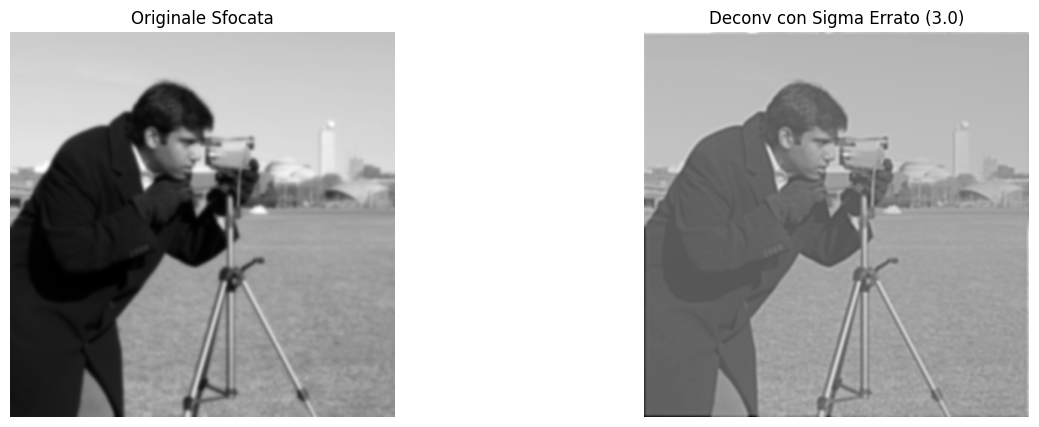

In [36]:
wrong_sigma = SIGMA * 1.5
psf_wrong = create_psf(original_image.shape, wrong_sigma)
reconstructed_wrong_psf = inverse_filter(blurred_image, psf_wrong, epsilon=5e-1)

show_images([blurred_image, reconstructed_wrong_psf],
            ["Originale Sfocata", f"Deconv con Sigma Errato ({wrong_sigma})"])

## Esperimento 2: Ricostruzione Iterativa (Gradient Descent)
Minimizzazione del Least Squares:

$$
L(x) = \frac{1}{2} \|Ax - y\|^2
$$

Aggiornamento iterativo:

$$
x^{k+1} = x^k + \alpha A^T (y - Ax^k)
$$

In [37]:
class IterativeDeblur:
    def __init__(self, psf_sigma):
        self.sigma = psf_sigma
        
    def A(self, x):
        return ndimage.gaussian_filter(x, sigma=self.sigma)
    
    def AT(self, x):
        return ndimage.gaussian_filter(x, sigma=self.sigma)
    
    def solve(self, y, iterations=50, x_init=None, verbose=True):
        if x_init is None:
            x = np.zeros_like(y)
        else:
            x = x_init.copy()
        history = []
        for i in range(iterations):
            Ax = self.A(x)
            residual = y - Ax
            g = self.AT(residual)
            Ag = self.A(g)
            norm_g_sq = np.sum(g**2)
            norm_Ag_sq = np.sum(Ag**2)
            if norm_Ag_sq < 1e-10:
                break
            alpha = norm_g_sq / norm_Ag_sq
            x = x + alpha * g
            update_norm = np.linalg.norm(alpha * g)
            history.append(update_norm)
            if verbose and i % 10 == 0:
                print(f"Iter {i}: Step Norm = {update_norm:.5f}")
        return x, history

solver = IterativeDeblur(psf_sigma=SIGMA)

### 2.1 Test di Convergenza e Inizializzazione

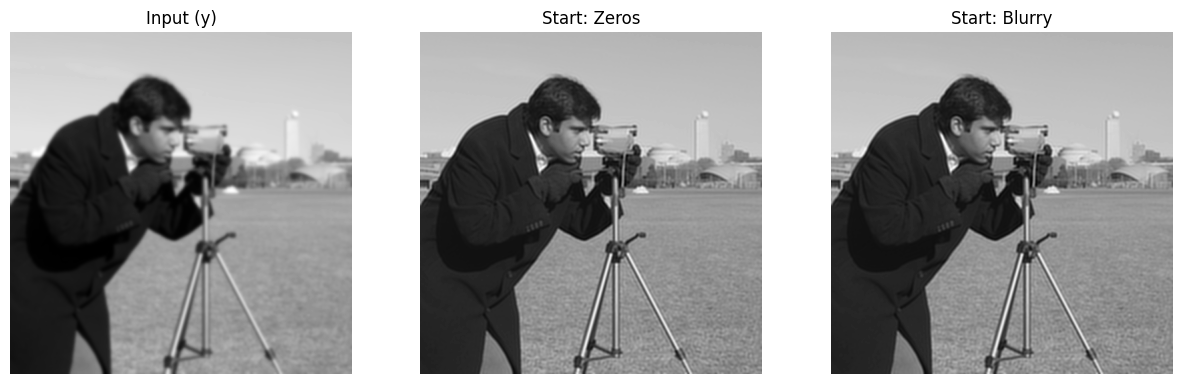

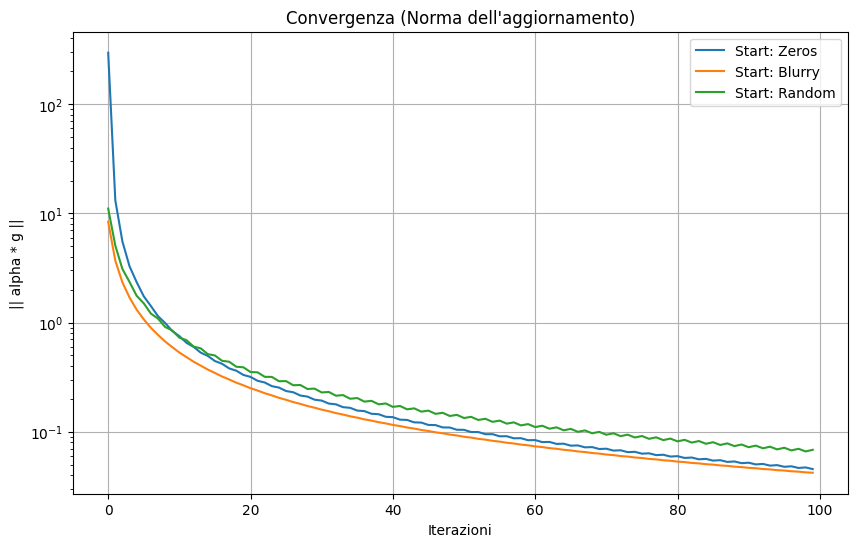

In [38]:
x_rec_zeros, hist_zeros = solver.solve(blurred_image, iterations=100, x_init=np.zeros_like(blurred_image), verbose=False)
x_rec_blur, hist_blur = solver.solve(blurred_image, iterations=100, x_init=blurred_image, verbose=False)
random_init = blurred_image + np.random.normal(0,0.1,blurred_image.shape)
x_rec_rand, hist_rand = solver.solve(blurred_image, iterations=100, x_init=random_init, verbose=False)

show_images([blurred_image, x_rec_zeros, x_rec_blur],
            ["Input (y)", "Start: Zeros", "Start: Blurry"])

plt.figure(figsize=(10,6))
plt.plot(hist_zeros, label='Start: Zeros')
plt.plot(hist_blur, label='Start: Blurry')
plt.plot(hist_rand, label='Start: Random')
plt.yscale('log')
plt.title('Convergenza (Norma dell\'aggiornamento)')
plt.xlabel('Iterazioni')
plt.ylabel('|| alpha * g ||')
plt.legend()
plt.grid(True)
plt.show()

### 2.2 Test su Immagine Rumorosa

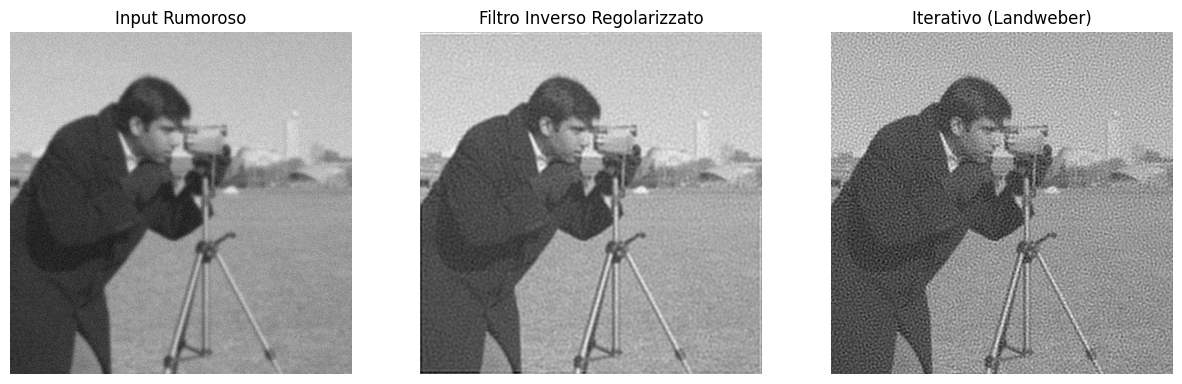

In [39]:
x_rec_noisy_iter, hist_noisy = solver.solve(y_noisy, iterations=50, x_init=y_noisy, verbose=False)
show_images([y_noisy, reconstructed_regularized, x_rec_noisy_iter],
            ["Input Rumoroso", "Filtro Inverso Regolarizzato", "Iterativo (Landweber)"])

### 2.3 Stabilità dell'inizializzazione con Rumore

Distanza euclidea tra le due soluzioni dopo 50 iterazioni: 480.8621


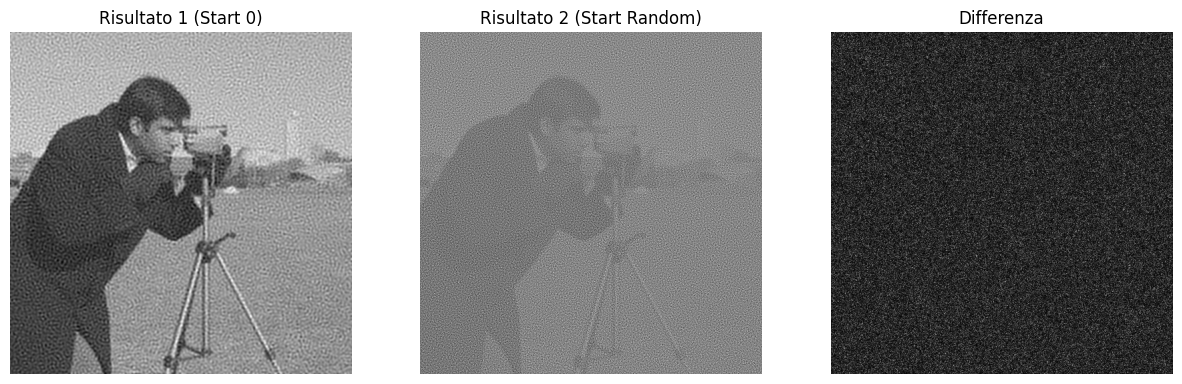

In [50]:
res1, _ = solver.solve(y_noisy, iterations=50, x_init=np.zeros_like(y_noisy), verbose=False)
rand_start = np.random.normal(0,1,y_noisy.shape)
res2, _ = solver.solve(y_noisy, iterations=50, x_init=rand_start, verbose=False)
diff_norm = np.linalg.norm(res1 - res2)
print(f"Distanza euclidea tra le due soluzioni dopo 50 iterazioni: {diff_norm:.4f}")

show_images([res1, res2, np.abs(res1-res2)],
            ["Risultato 1 (Start 0)", "Risultato 2 (Start Random)", "Differenza"])